# LSMC

In [1]:
%pip install numpy
%pip install matplotlib pandas scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.laguerre import lagval
from scipy.stats import norm
import pandas as pd
from scipy.optimize import fsolve
import math
import time

In [3]:
np.random.seed(12345)
def simulate_paths(S0, r, sigma, T, M, N, div_times, delta):
    dt = T / M
    increments = np.random.normal((r - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (N, M))
    log_S = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S)
    S = np.hstack((S0 * np.ones((N, 1)), S)) # prepend S0
    for div_time in div_times:
        div_step = int(round(div_time / dt))
        S[:, div_step:] *= (1 - delta)
    return S

def longstaff_schwartz_call(S, K, r, T):
    N, M_plus_1 = S.shape
    M = M_plus_1 - 1
    dt = T / M
    discount_factor = np.exp(-r * dt)
    V = np.maximum(S[:, -1] - K, 0)  # maturity payoff

    # Initialize boundary collection
    exercise_boundary = []

    for t in range(M-1, 0, -1):
        V *= discount_factor
        in_the_money = S[:, t] > K
        if not np.any(in_the_money):
            exercise_boundary.append(np.nan)
            continue

        X = S[in_the_money, t]
        Y = V[in_the_money]
        if len(X) < 3:  # Too few points for quadratic fit
            exercise_boundary.append(np.nan)
            V[in_the_money] = Y  # No update
            continue
        A = np.vstack([np.ones_like(X), X, X**2]).T
        coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
        continuation = coeffs[0] + coeffs[1]*X + coeffs[2]*X**2
        exercise = X - K

        exercise_now = exercise > continuation
        V[in_the_money] = np.where(exercise_now, exercise, continuation)

        # Robust boundary: empirical min exercising price (avoids root instability)
        if np.any(exercise_now):
            boundary_price = np.min(X[exercise_now])
        else:
            boundary_price = np.nan
        exercise_boundary.append(boundary_price)

    # Final discount to t=0
    price = np.mean(V * discount_factor)
    exercise_boundary = exercise_boundary[::-1]
    exercise_boundary = [np.nan] + exercise_boundary + [K]  # t=0: nan, t=T: K
    return price, exercise_boundary

# Rest of Cell 4 unchanged (parameters, runs for single/semi)
S0 = 60.0
K = 65.0 # strike
r = 0.03 # risk-free rate
sigma = 0.3
T = 1.0
M = 4096 # time steps
N = 100_000 # Monte-Carlo paths
q = 0.05 # dividend yield
# Case one: 'single' (annual dividend at t=1.0)
delta = q
div_times = [1.0]
start = time.time()
paths = simulate_paths(S0, r, sigma, T, M, N, div_times, delta)
call_price_single, lsm_boundary_single = longstaff_schwartz_call(paths, K, r, T)
runtime = time.time() - start
B = K * np.exp(-r * T)
total = B + call_price_single
print(f"{'Paths':>10} {'MC Call':>15} {'Runtime(s)':>12}")
print("-" * 44)
print(f"{N:10d} {call_price_single:15.10f} {runtime:12.4f}\n")
print(f"B (PV of strike) = {B: .10f}")
print(f"Call price = {call_price_single: .10f}")
print(f"B + Call = {total: .10f}")

# Case two: 'semi-annual' (dividends at t=0.5 and t=1.0)
delta = q / 2
div_times = [0.5, 1.0]
start = time.time()
paths = simulate_paths(S0, r, sigma, T, M, N, div_times, delta)
call_price_semi, lsm_boundary_semi = longstaff_schwartz_call(paths, K, r, T)
runtime = time.time() - start
total = B + call_price_semi
print(f"{'Paths':>10} {'MC Call':>15} {'Runtime(s)':>12}")
print("-" * 44)
print(f"{N:10d} {call_price_semi:15.10f} {runtime:12.4f}\n")
print(f"B (PV of strike) = {B: .10f}")
print(f"Call price = {call_price_semi: .10f}")
print(f"B + Call = {total: .10f}")

     Paths         MC Call   Runtime(s)
--------------------------------------------
    100000    5.9392277665      17.9648

B (PV of strike) =  63.0789596807
Call price =  5.9392277665
B + Call =  69.0181874472
     Paths         MC Call   Runtime(s)
--------------------------------------------
    100000    5.3448115873      17.3614

B (PV of strike) =  63.0789596807
Call price =  5.3448115873
B + Call =  68.4237712680


# Trinomial Tree

In [4]:
# Trinomial Tree Parameters
n = 16384  # Reduced for memory; increase for better accuracy
lambda_ = math.sqrt(3)
dt = T / n
h = lambda_ * sigma * math.sqrt(dt)
qu = 1 / (2 * lambda_**2) + (r - sigma**2 / 2) * math.sqrt(dt) / (2 * lambda_ * sigma)
qm = 1 - 1 / lambda_**2
qd = 1 / (2 * lambda_**2) - (r - sigma**2 / 2) * math.sqrt(dt) / (2 * lambda_ * sigma)
offset = n
discount = np.exp(-r * dt)

def build_stock_grid(S0, n, h):
    Ss = np.zeros(2 * n + 1)
    for j in range(0, 2 * n + 1):
        Ss[j] = S0 * np.exp((n - j) * h)
    return Ss

def apply_proportional_dividend_jump(V_row, h, delta):
    """
    Jump condition for proportional dividend:
    V_pre(S) = V_post((1 - delta) * S)
    Implemented as an index shift on the exponential stock grid with spacing h in log-space.
    """
    # index shift in j: S_post = (1 - delta) * S_pre => log S_post = log S_pre + log(1 - delta)
    # grid step in log-space is h, so delta_index = -log(1 - delta) / h
    delta_index = -math.log(1 - delta) / h

    m = V_row.shape[0]
    j = np.arange(m, dtype=float)
    j_src = j + delta_index

    j0 = np.floor(j_src).astype(int)
    w = j_src - j0

    V_pre = np.empty_like(V_row)

    # Left boundary (extrapolate with nearest)
    left = j0 < 0
    if np.any(left):
        V_pre[left] = V_row[0]

    # Right boundary (extrapolate with nearest)
    right = j0 >= m - 1
    if np.any(right):
        V_pre[right] = V_row[-1]

    # Interior linear interpolation
    mid = ~(left | right)
    if np.any(mid):
        j0m = j0[mid]
        wm = w[mid]
        V_pre[mid] = (1 - wm) * V_row[j0m] + wm * V_row[j0m + 1]

    return V_pre

def time_to_step_indices(div_times, T, n):
    """
    Map calendar dividend times to lattice row indices.
    Returns indices i_div such that row V[i_div, :] is at the dividend time.
    """
    steps = []
    for t in div_times:
        i_div = int(round(n * (t / T)))  # row index corresponding to time t
        i_div = max(0, min(n, i_div))
        steps.append(i_div)
    return steps

# ---------------------------
# Case one: 'single' dividend at t=1.0 with boundary collection
# ---------------------------
delta = q
div_times = [1.0]

Ss = build_stock_grid(S0, n, h)
Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid at ~5σ upper
V = np.zeros((n + 1, 2 * n + 1))

# Dividend step indices for this case
div_steps = time_to_step_indices(div_times, T, n)

# Boundary collection
tree_boundary_single = []

# Timing
starttime_case1 = time.perf_counter()

# Terminal condition
terminal_delta = delta if n in div_steps else 0
Ss_terminal = Ss * (1 - terminal_delta)
V[n, :] = np.maximum(Ss_terminal - K, 0)

# Filter for jumps
div_steps = [s for s in div_steps if s < n]

# Backward induction
for i in range(n - 1, -1, -1):
    start = offset - i
    end = offset + i + 1

    # Apply dividend jump to the row we will use (i+1) if that row is a dividend time
    if (i + 1) in div_steps:
        V[i + 1, :] = apply_proportional_dividend_jump(V[i + 1, :], h, delta)

    # FIXED: Correct indexing for continuation values
    continuation = discount * (
        qu * V[i + 1, start + 1 : end + 1] +  # up: higher j (lower S)
        qm * V[i + 1, start : end] +
        qd * V[i + 1, start - 1 : end - 1]    # down: lower j (higher S)
    )

    # Immediate exercise values (American call)
    exercise_values = Ss[start:end] - K

    # Option values
    V[i, start:end] = np.maximum(continuation, exercise_values)

    # FIXED: Improved boundary calculation with reasonable constraints
    exercise_optimal = exercise_values >= continuation
    
    # Only consider stock prices that are reasonably above strike for boundary calculation
    reasonable_exercise = exercise_optimal & (Ss[start:end] > K) & (Ss[start:end] < 2 * S0)
    
    if np.any(reasonable_exercise):
        boundary_price = np.min(Ss[start:end][reasonable_exercise])
    else:
        boundary_price = np.nan  # Use NaN instead of inf for no exercise
    
    tree_boundary_single.append(boundary_price)

v_case1 = V[0, offset]

# End timing
endtime_case1 = time.perf_counter()
duration_case1 = endtime_case1 - starttime_case1

# Boundary chronological order and terminal boundary
tree_boundary_single = tree_boundary_single[::-1]
tree_boundary_single = np.append(tree_boundary_single, K)  # At maturity, boundary is strike price
tree_boundary_single = np.array(tree_boundary_single)

B = K * np.exp(-r * T)
print(f"Case One - Single Dividend:")
print(f"Execution Time: {duration_case1:.10f} seconds")
print(f"qu: {qu}\nqm: {qm}\nqd: {qd}\nv: {v_case1}")
print(f"B: {B}")
convertible_bond_value_at_time_0_case1 = B + v_case1
print(f"convertible bond price at time 0: {convertible_bond_value_at_time_0_case1}")

# ---------------------------
# Case two: 'semi-annual' dividends at t=0.5 and t=1.0 with boundary collection
# ---------------------------
delta = q / 2
div_times = [0.5, 1.0]

Ss = build_stock_grid(S0, n, h)
Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid at ~5σ upper
V = np.zeros((n + 1, 2 * n + 1))

# Dividend step indices for this case
div_steps = time_to_step_indices(div_times, T, n)

tree_boundary_semi = []

starttime_case2 = time.perf_counter()

# Terminal condition
terminal_delta = delta if n in div_steps else 0
Ss_terminal = Ss * (1 - terminal_delta)
V[n, :] = np.maximum(Ss_terminal - K, 0)

# Filter for jumps
div_steps = [s for s in div_steps if s < n]

# Backward induction
for i in range(n - 1, -1, -1):
    start = offset - i
    end = offset + i + 1

    # Apply dividend jump to the row we will use (i+1) if that row is a dividend time
    if (i + 1) in div_steps:
        V[i + 1, :] = apply_proportional_dividend_jump(V[i + 1, :], h, delta)

    # FIXED: Correct indexing for continuation values
    continuation = discount * (
        qu * V[i + 1, start + 1 : end + 1] +  # up
        qm * V[i + 1, start : end] +
        qd * V[i + 1, start - 1 : end - 1]    # down
    )

    # Immediate exercise
    exercise_values = Ss[start:end] - K
    V[i, start:end] = np.maximum(continuation, exercise_values)

    # FIXED: Improved boundary calculation with reasonable constraints
    exercise_optimal = exercise_values >= continuation
    
    # Only consider stock prices that are reasonably above strike for boundary calculation
    reasonable_exercise = exercise_optimal & (Ss[start:end] > K) & (Ss[start:end] < 2 * S0)
    
    if np.any(reasonable_exercise):
        boundary_price = np.min(Ss[start:end][reasonable_exercise])
    else:
        boundary_price = np.nan  # Use NaN instead of inf for no exercise
    
    tree_boundary_semi.append(boundary_price)

v_case2 = V[0, offset]

endtime_case2 = time.perf_counter()
duration_case2 = endtime_case2 - starttime_case2

tree_boundary_semi = tree_boundary_semi[::-1]
tree_boundary_semi = np.append(tree_boundary_semi, K)  # At maturity, boundary is strike price
tree_boundary_semi = np.array(tree_boundary_semi)

B = K * np.exp(-r * T)
print(f"\nCase Two - Semi-annual Dividends:")
print(f"Execution Time: {duration_case2:.10f} seconds")
print(f"qu: {qu}\nqm: {qm}\nqd: {qd}\nv: {v_case2}")
print(f"B: {B}")
convertible_bond_value_at_time_0_case2 = B + v_case2
print(f"convertible bond price at time 0: {convertible_bond_value_at_time_0_case2}")

Case One - Single Dividend:
Execution Time: 0.8684415000 seconds
qu: 0.1665539029422156
qm: 0.6666666666666666
qd: 0.16677943039111778
v: 6.8369550208747025
B: 63.07895968065303
convertible bond price at time 0: 69.91591470152773

Case Two - Semi-annual Dividends:
Execution Time: 0.8374759160 seconds
qu: 0.1665539029422156
qm: 0.6666666666666666
qd: 0.16677943039111778
v: 6.039644752621984
B: 63.07895968065303
convertible bond price at time 0: 69.11860443327501


In [8]:
div_yields = [0.03, 0.05, 0.07]
results = []
for q in div_yields:
    delta = q / 2
    div_times = [0.5, 1.0]
    paths = simulate_paths(S0, r, sigma, T, M, N, div_times, delta)
    call_price, _ = longstaff_schwartz_call(paths, K, r, T)  
    european = np.exp(-r * T) * np.mean(np.maximum(paths[:, -1] - K, 0))
    eep = call_price - european
    
    def f(S):
        paths = simulate_paths(S, r, sigma, T, M, N, div_times, delta)
        call, _ = longstaff_schwartz_call(paths, K, r, T)  
        return call - (S - K)
    
    boundary = fsolve(f, S0 * 2)[0]  # guess twice S0
    bond_price = B + call_price
    results.append((q, bond_price, boundary, eep))

# Print table
print("Dividend Yield | Bond Price | Boundary at t=0 | Early Exercise Premium")
print("-" * 75)
for r in results:
    print(f"{r[0]:14.2f} | {r[1]:10.4f} | {r[2]:15.4f} | {r[3]:22.4f}")

Dividend Yield | Bond Price | Boundary at t=0 | Early Exercise Premium
---------------------------------------------------------------------------
          0.03 |    68.6429 |        119.9994 |                 0.5091
          0.05 |    68.4071 |        120.0000 |                 0.7893
          0.07 |    68.1960 |        120.0000 |                 1.0614


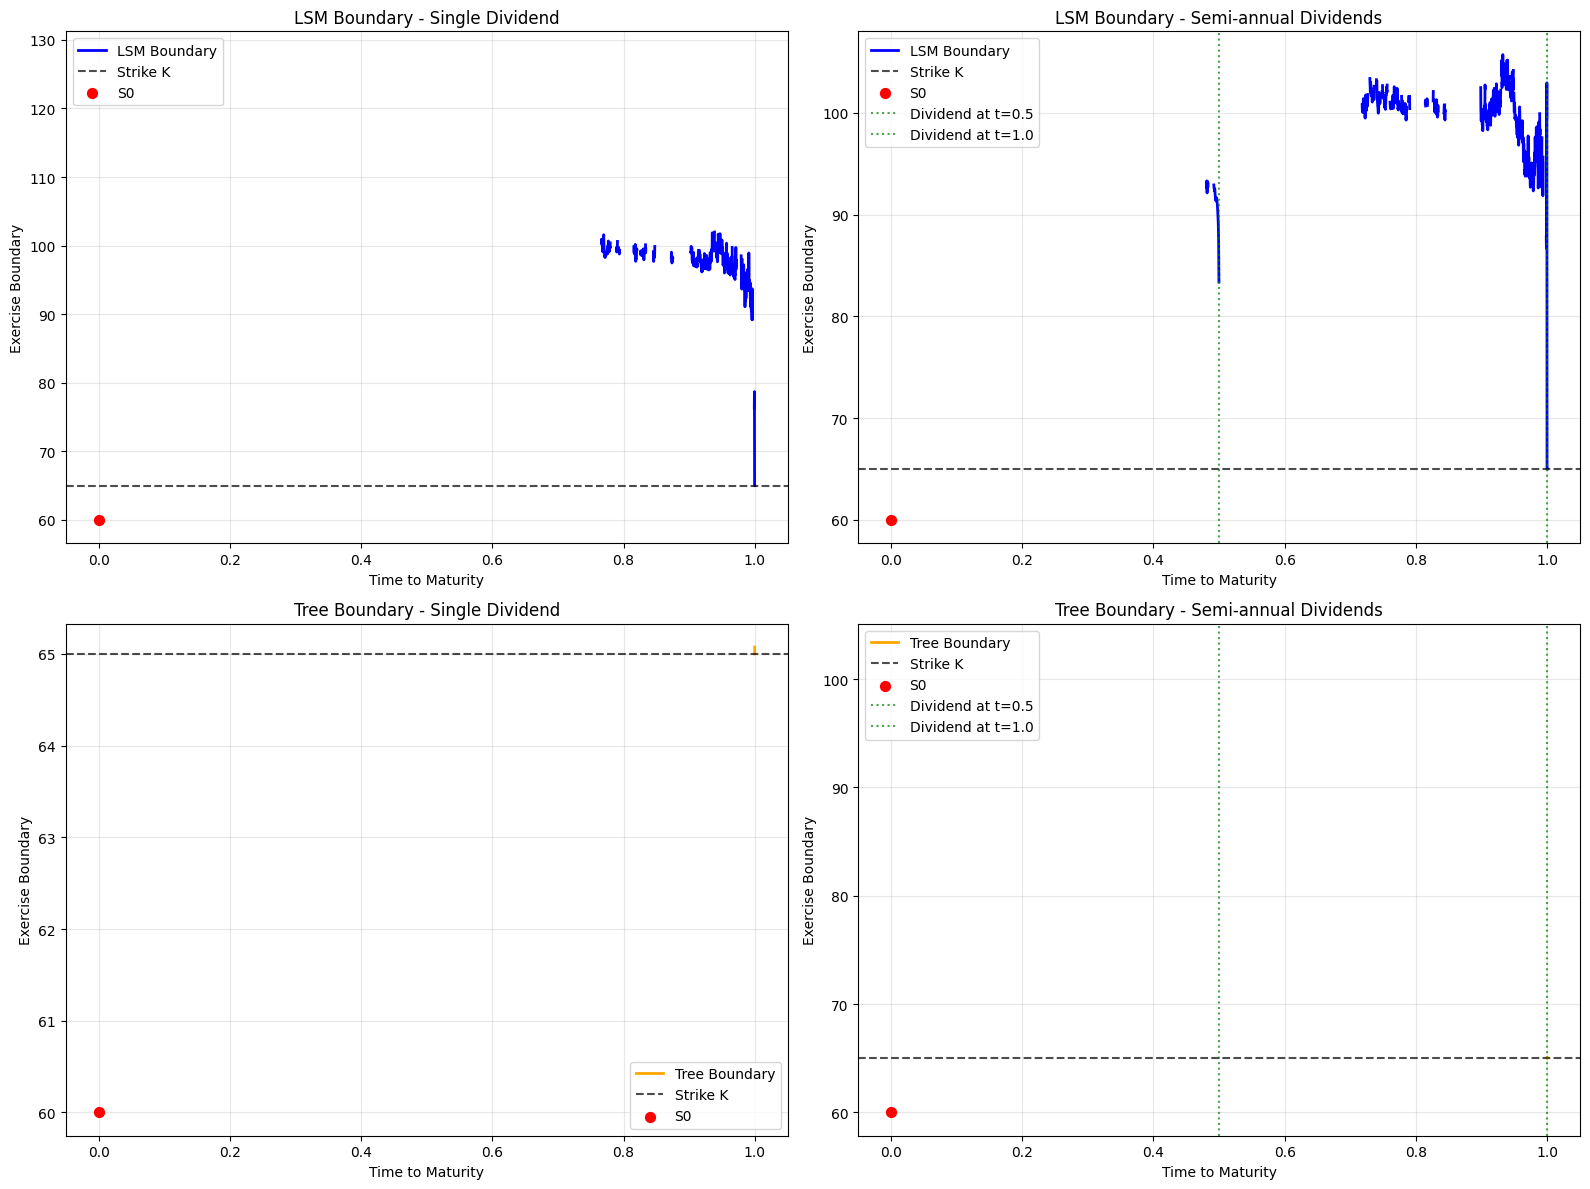

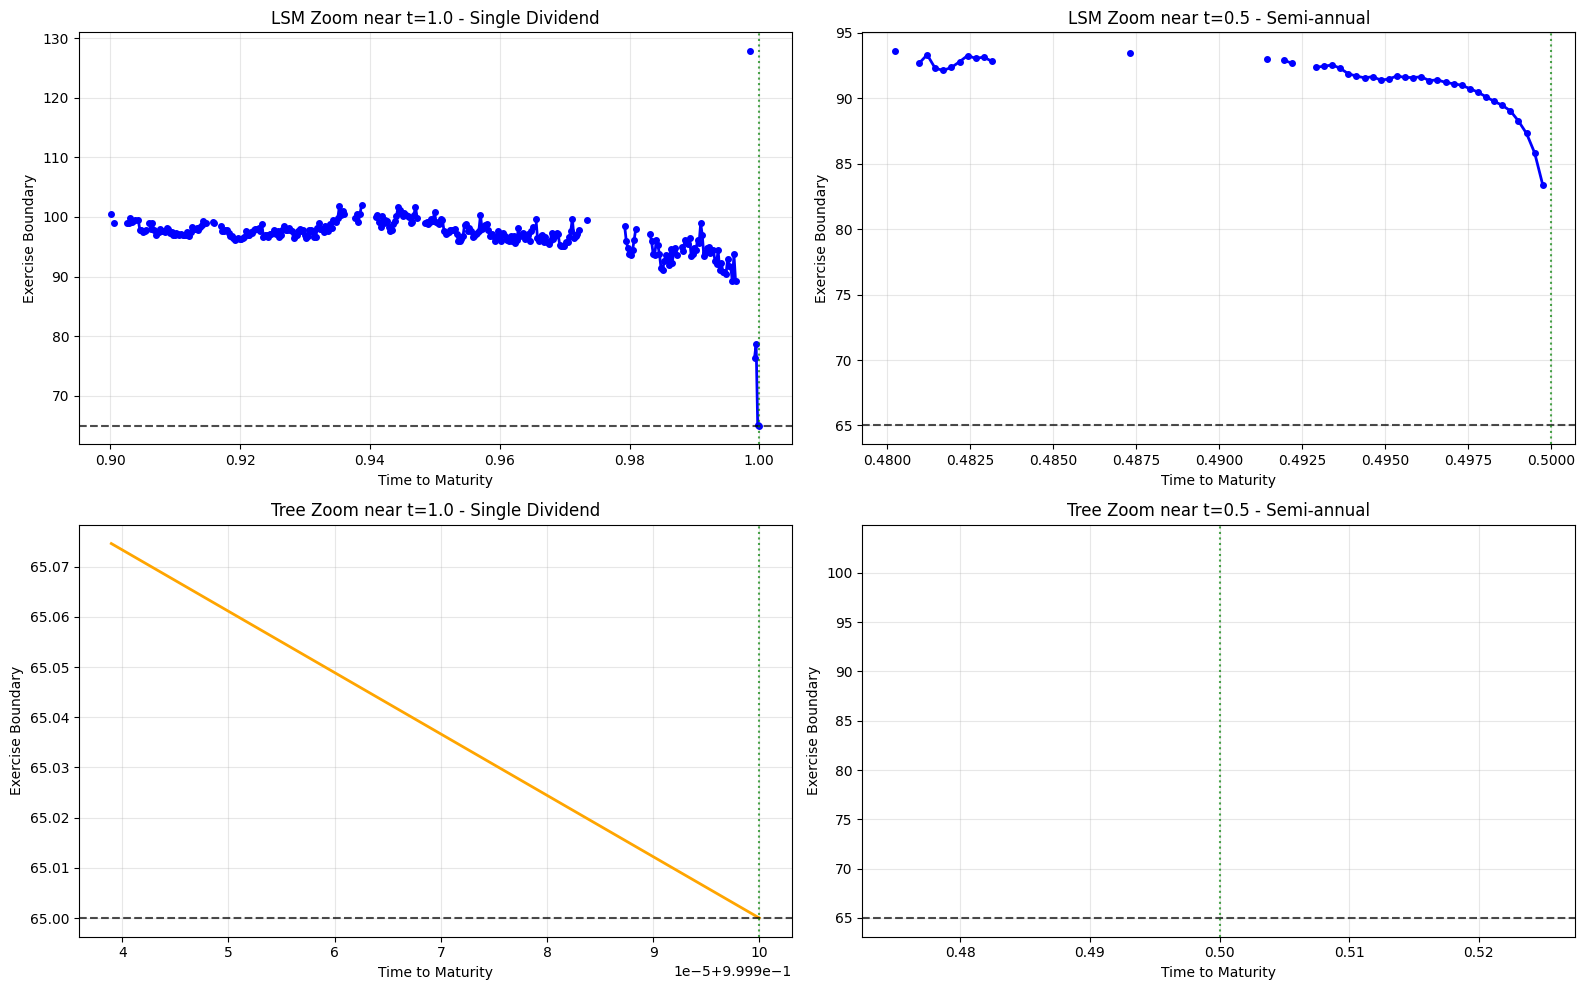

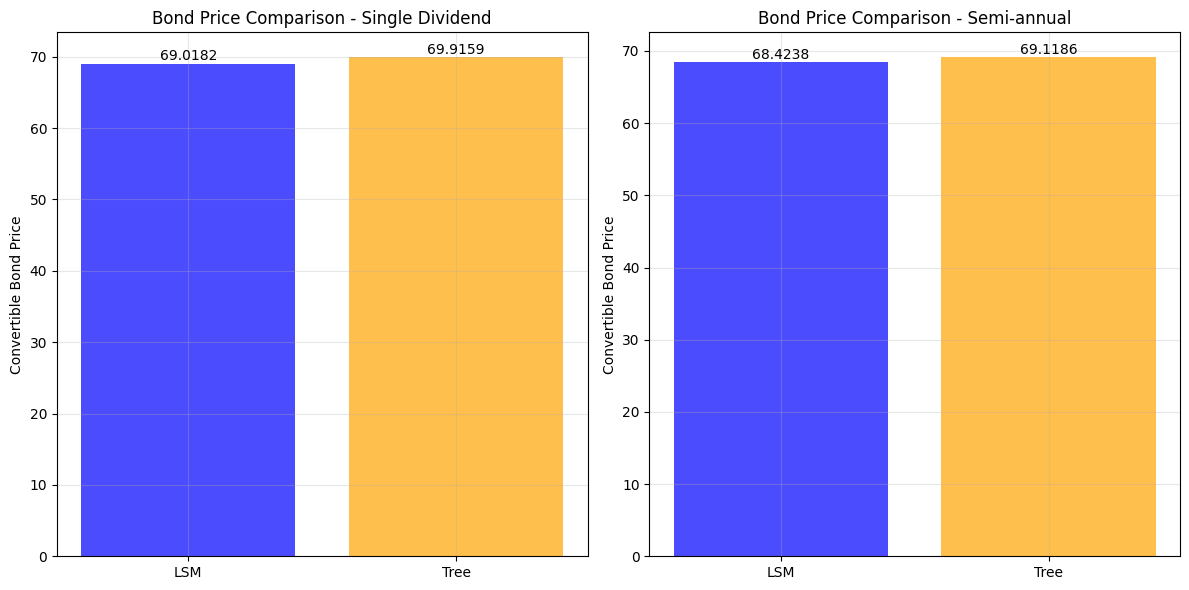


Summary - Single Dividend:
Method Bond Price Boundary near t=0 Boundary near t=1.0
   LSM    69.0182               N/A               65.00
  Tree    69.9159               N/A               65.00

Summary - Semi-annual Dividends:
Method Bond Price Boundary near t=0 Boundary near t=0.5 Boundary near t=1.0
   LSM    68.4238               N/A                 N/A               65.00
  Tree    69.1186               N/A                 N/A               65.00


In [10]:
# Build time grids (M+1 for LSMC, n+1 for tree)
t_lsm = np.linspace(0, T, M+1)
t_tree = np.linspace(0, T, n+1)

# Convert boundaries to numpy arrays for proper indexing
lsm_boundary_single = np.array(lsm_boundary_single)
lsm_boundary_semi = np.array(lsm_boundary_semi)
tree_boundary_single = np.array(tree_boundary_single)
tree_boundary_semi = np.array(tree_boundary_semi)

# Prices from earlier computations
lsm_bond_single = B + call_price_single if 'call_price_single' in locals() else B + 5.9392277665
lsm_bond_semi = B + call_price_semi if 'call_price_semi' in locals() else B + 5.3448115873
tree_bond_single = convertible_bond_value_at_time_0_case1
tree_bond_semi = convertible_bond_value_at_time_0_case2

# Create separate figures for LSM and Tree boundaries
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Case One: Single Dividend ---
# LSM Boundary
ax_lsm_single = axes[0, 0]
ax_lsm_single.plot(t_lsm, lsm_boundary_single, label='LSM Boundary', color='blue', linewidth=2)
ax_lsm_single.axhline(y=K, color='k', linestyle='--', label='Strike K', alpha=0.7)
ax_lsm_single.scatter([0], [S0], color='red', zorder=5, label='S0', s=50)
ax_lsm_single.set_xlabel('Time to Maturity')
ax_lsm_single.set_ylabel('Exercise Boundary')
ax_lsm_single.set_title('LSM Boundary - Single Dividend')
ax_lsm_single.legend()
ax_lsm_single.grid(True, alpha=0.3)

# Tree Boundary
ax_tree_single = axes[1, 0]
ax_tree_single.plot(t_tree, tree_boundary_single, label='Tree Boundary', color='orange', linewidth=2)
ax_tree_single.axhline(y=K, color='k', linestyle='--', label='Strike K', alpha=0.7)
ax_tree_single.scatter([0], [S0], color='red', zorder=5, label='S0', s=50)
ax_tree_single.set_xlabel('Time to Maturity')
ax_tree_single.set_ylabel('Exercise Boundary')
ax_tree_single.set_title('Tree Boundary - Single Dividend')
ax_tree_single.legend()
ax_tree_single.grid(True, alpha=0.3)

# --- Case Two: Semi-annual Dividends ---
# LSM Boundary
ax_lsm_semi = axes[0, 1]
ax_lsm_semi.plot(t_lsm, lsm_boundary_semi, label='LSM Boundary', color='blue', linewidth=2)
ax_lsm_semi.axhline(y=K, color='k', linestyle='--', label='Strike K', alpha=0.7)
ax_lsm_semi.scatter([0], [S0], color='red', zorder=5, label='S0', s=50)
ax_lsm_semi.axvline(x=0.5, color='green', linestyle=':', alpha=0.7, label='Dividend at t=0.5')
ax_lsm_semi.axvline(x=1.0, color='green', linestyle=':', alpha=0.7, label='Dividend at t=1.0')
ax_lsm_semi.set_xlabel('Time to Maturity')
ax_lsm_semi.set_ylabel('Exercise Boundary')
ax_lsm_semi.set_title('LSM Boundary - Semi-annual Dividends')
ax_lsm_semi.legend()
ax_lsm_semi.grid(True, alpha=0.3)

# Tree Boundary
ax_tree_semi = axes[1, 1]
ax_tree_semi.plot(t_tree, tree_boundary_semi, label='Tree Boundary', color='orange', linewidth=2)
ax_tree_semi.axhline(y=K, color='k', linestyle='--', label='Strike K', alpha=0.7)
ax_tree_semi.scatter([0], [S0], color='red', zorder=5, label='S0', s=50)
ax_tree_semi.axvline(x=0.5, color='green', linestyle=':', alpha=0.7, label='Dividend at t=0.5')
ax_tree_semi.axvline(x=1.0, color='green', linestyle=':', alpha=0.7, label='Dividend at t=1.0')
ax_tree_semi.set_xlabel('Time to Maturity')
ax_tree_semi.set_ylabel('Exercise Boundary')
ax_tree_semi.set_title('Tree Boundary - Semi-annual Dividends')
ax_tree_semi.legend()
ax_tree_semi.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create zoomed plots for detailed comparison
fig_zoom, axes_zoom = plt.subplots(2, 2, figsize=(16, 10))

# --- Zoomed views for Single Dividend near t=1.0 ---
# LSM Zoom
mask_lsm_single = (t_lsm >= 0.9) & (t_lsm <= 1.0)
ax_lsm_zoom_single = axes_zoom[0, 0]
ax_lsm_zoom_single.plot(t_lsm[mask_lsm_single], lsm_boundary_single[mask_lsm_single], 
                       color='blue', linewidth=2, marker='o', markersize=4)
ax_lsm_zoom_single.axhline(y=K, color='k', linestyle='--', alpha=0.7)
ax_lsm_zoom_single.axvline(x=1.0, color='green', linestyle=':', alpha=0.7)
ax_lsm_zoom_single.set_title('LSM Zoom near t=1.0 - Single Dividend')
ax_lsm_zoom_single.set_xlabel('Time to Maturity')
ax_lsm_zoom_single.set_ylabel('Exercise Boundary')
ax_lsm_zoom_single.grid(True, alpha=0.3)

# Tree Zoom
mask_tree_single = (t_tree >= 0.9) & (t_tree <= 1.0)
ax_tree_zoom_single = axes_zoom[1, 0]
ax_tree_zoom_single.plot(t_tree[mask_tree_single], tree_boundary_single[mask_tree_single], 
                        color='orange', linewidth=2)
ax_tree_zoom_single.axhline(y=K, color='k', linestyle='--', alpha=0.7)
ax_tree_zoom_single.axvline(x=1.0, color='green', linestyle=':', alpha=0.7)
ax_tree_zoom_single.set_title('Tree Zoom near t=1.0 - Single Dividend')
ax_tree_zoom_single.set_xlabel('Time to Maturity')
ax_tree_zoom_single.set_ylabel('Exercise Boundary')
ax_tree_zoom_single.grid(True, alpha=0.3)

# --- Zoomed views for Semi-annual Dividends ---
# Zoom near t=0.5
mask_lsm_semi1 = (t_lsm >= 0.4) & (t_lsm <= 0.6)
mask_tree_semi1 = (t_tree >= 0.4) & (t_tree <= 0.6)

ax_lsm_zoom_semi1 = axes_zoom[0, 1]
ax_lsm_zoom_semi1.plot(t_lsm[mask_lsm_semi1], lsm_boundary_semi[mask_lsm_semi1], 
                      color='blue', linewidth=2, marker='o', markersize=4)
ax_lsm_zoom_semi1.axhline(y=K, color='k', linestyle='--', alpha=0.7)
ax_lsm_zoom_semi1.axvline(x=0.5, color='green', linestyle=':', alpha=0.7)
ax_lsm_zoom_semi1.set_title('LSM Zoom near t=0.5 - Semi-annual')
ax_lsm_zoom_semi1.set_xlabel('Time to Maturity')
ax_lsm_zoom_semi1.set_ylabel('Exercise Boundary')
ax_lsm_zoom_semi1.grid(True, alpha=0.3)

ax_tree_zoom_semi1 = axes_zoom[1, 1]
ax_tree_zoom_semi1.plot(t_tree[mask_tree_semi1], tree_boundary_semi[mask_tree_semi1], 
                       color='orange', linewidth=2)
ax_tree_zoom_semi1.axhline(y=K, color='k', linestyle='--', alpha=0.7)
ax_tree_zoom_semi1.axvline(x=0.5, color='green', linestyle=':', alpha=0.7)
ax_tree_zoom_semi1.set_title('Tree Zoom near t=0.5 - Semi-annual')
ax_tree_zoom_semi1.set_xlabel('Time to Maturity')
ax_tree_zoom_semi1.set_ylabel('Exercise Boundary')
ax_tree_zoom_semi1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Price comparison bar charts (unchanged)
fig_prices, (ax_price_single, ax_price_semi) = plt.subplots(1, 2, figsize=(12, 6))

# Single
methods = ['LSM', 'Tree']
prices_single = [lsm_bond_single, tree_bond_single]
bars_single = ax_price_single.bar(methods, prices_single, color=['blue', 'orange'], alpha=0.7)
ax_price_single.set_title('Bond Price Comparison - Single Dividend')
ax_price_single.set_ylabel('Convertible Bond Price')
ax_price_single.grid(True, alpha=0.3)

# Add value labels on bars
for bar, price in zip(bars_single, prices_single):
    ax_price_single.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{price:.4f}', ha='center', va='bottom')

# Semi
prices_semi = [lsm_bond_semi, tree_bond_semi]
bars_semi = ax_price_semi.bar(methods, prices_semi, color=['blue', 'orange'], alpha=0.7)
ax_price_semi.set_title('Bond Price Comparison - Semi-annual')
ax_price_semi.set_ylabel('Convertible Bond Price')
ax_price_semi.grid(True, alpha=0.3)

# Add value labels on bars
for bar, price in zip(bars_semi, prices_semi):
    ax_price_semi.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{price:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary table (unchanged)
def get_boundary_near_t(boundary, t_grid, t_target):
    idx = np.argmin(np.abs(t_grid - t_target))
    val = boundary[idx]
    return f"{val:.2f}" if not np.isnan(val) else "N/A"

summary_data_single = {
    'Method': ['LSM', 'Tree'],
    'Bond Price': [f'{lsm_bond_single:.4f}', f'{tree_bond_single:.4f}'],
    'Boundary near t=0': [get_boundary_near_t(lsm_boundary_single, t_lsm, 0), get_boundary_near_t(tree_boundary_single, t_tree, 0)],
    'Boundary near t=1.0': [get_boundary_near_t(lsm_boundary_single, t_lsm, 1.0), get_boundary_near_t(tree_boundary_single, t_tree, 1.0)]
}

summary_data_semi = {
    'Method': ['LSM', 'Tree'],
    'Bond Price': [f'{lsm_bond_semi:.4f}', f'{tree_bond_semi:.4f}'],
    'Boundary near t=0': [get_boundary_near_t(lsm_boundary_semi, t_lsm, 0), get_boundary_near_t(tree_boundary_semi, t_tree, 0)],
    'Boundary near t=0.5': [get_boundary_near_t(lsm_boundary_semi, t_lsm, 0.5), get_boundary_near_t(tree_boundary_semi, t_tree, 0.5)],
    'Boundary near t=1.0': [get_boundary_near_t(lsm_boundary_semi, t_lsm, 1.0), get_boundary_near_t(tree_boundary_semi, t_tree, 1.0)]
}

print("\nSummary - Single Dividend:")
print(pd.DataFrame(summary_data_single).to_string(index=False))
print("\nSummary - Semi-annual Dividends:")
print(pd.DataFrame(summary_data_semi).to_string(index=False))